In [ ]:
# Standard library imports
import os
import sys
import time
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from functools import wraps

# The notebooks live in Agents/ while shared helpers live in the repository root.
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Shared supporting modules from the repository root
from color_logger import log_info, log_success, log_error, log_warn, log_section
from resilience import fail_gracefully
from mock_llm import MockLLM, MockVectorDB, MockResponse

log_success("All imports successful")

[SUCCESS 18:28:53] All imports successful


In [2]:
import os
os.environ["LLM_PROVIDER"] = "openai"

# ── Environment Detection & Simulation Mode Toggle ─────────────

# If an API key is found in .env or via getpass, live mode activates.
# Otherwise, Simulation Mode engages the MockLLM and MockVectorDB.

log_section("Environment Detection")

# Attempt to load .env (no-op if file missing)
try:
    from dotenv import load_dotenv
    load_dotenv()
    log_info("Loaded .env file")
except ImportError:
    log_warn("python-dotenv not installed — skipping .env loading")

# Check for API key
api_key = os.getenv("OPENAI_API_KEY", "").strip()

if not api_key:
    try:
        import getpass
        # In non-interactive environments, this will remain empty
        api_key = getpass.getpass(
            "Enter OpenAI API key (or press Enter for Simulation Mode): "
        ).strip()
    except (EOFError, OSError, Exception):
        api_key = ""

# ── Initialize clients based on mode ───────────────────────────
SIMULATION_MODE = not bool(api_key)

if SIMULATION_MODE:
    llm_client = MockLLM()
    vector_db = MockVectorDB()
    log_warn("SIMULATION MODE active — using MockLLM and MockVectorDB")
    log_info("No API key required. All agent demos will run with mock data.")
else:
    # ── Live LLM wrapper matching MockLLM.generate() interface ─
    try:
        from openai import OpenAI as _OpenAI

        class _LiveLLM:
            """Wraps OpenAI GPT-4o to match MockLLM.generate() interface.
            Returns MockResponse-compatible objects so downstream agent
            code works unchanged."""

            _INTENT_KW = {
                "service_outage": ["outage", "down", "not working", "internet", "offline"],
                "billing_issue": ["bill", "charge", "invoice", "payment", "refund"],
                "complex_technical": ["configure", "setup", "integrate", "deploy", "debug"],
                "marketing_campaign_plan": ["marketing", "campaign", "plan", "launch"],
                "healthcare_query": ["health", "medical", "patient", "diagnosis", "clinical"],
            }

            def __init__(self, client, model="gpt-4o"):
                self._client = client
                self._model = model
                self._fallback = MockLLM()

            def _detect_intent(self, prompt):
                lower = prompt.lower()
                for intent, kws in self._INTENT_KW.items():
                    if any(kw in lower for kw in kws):
                        return intent
                return "general_inquiry"

            def generate(self, prompt, **kwargs):
                try:
                    resp = self._client.chat.completions.create(
                        model=self._model,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=1024,
                    )
                    content = resp.choices[0].message.content
                    intent = self._detect_intent(prompt)
                    return MockResponse(
                        content=content,
                        intent=intent,
                        confidence=0.90,
                        reasoning_steps=["Live LLM call via OpenAI GPT-4o"],
                        strategy="full_autonomous_resolution",
                        required_tools=[],
                        escalation_risk=0.1,
                        metadata={"provider": "openai", "model": self._model},
                    )
                except Exception as e:
                    log_warn(f"OpenAI API error, falling back to MockLLM: {e}")
                    return self._fallback.generate(prompt, **kwargs)

        _oai = _OpenAI(api_key=api_key)
        llm_client = _LiveLLM(_oai, model="gpt-4o")
        vector_db = MockVectorDB()
        log_success(f"LIVE MODE — OpenAI GPT-4o (key ...{api_key[-4:]})")
        log_info("Real API calls with MockLLM fallback on errors.")
    except Exception as e:
        log_warn(f"Failed to init OpenAI client: {e} — falling back to MockLLM")
        llm_client = MockLLM()
        vector_db = MockVectorDB()
        SIMULATION_MODE = True



────────────────────────────────────────────────────────────
  Environment Detection
────────────────────────────────────────────────────────────

[INFO  18:28:53] Loaded .env file
[INFO  18:28:54] MockVectorDB initialized with 0 pre-seeded episodic records
[SUCCESS 18:28:54] LIVE MODE — OpenAI GPT-4o (key ...SMYA)
[INFO  18:28:54] Real API calls with MockLLM fallback on errors.


---
## 3. Planning Agent


While Autonomous Decision-Making agents excel at real-time, single-step responses, many real-world challenges require breaking down complex objectives into sequences of smaller, manageable tasks executed over extended periods. The transition from reactive decision-making to proactive planning represents a significant leap in agent sophistication.

Planning agents master several interconnected capabilities: **decomposing** high-level goals into actionable subtasks, **sequencing** tasks appropriately, **allocating** resources, **monitoring** progress, and **adapting** plans dynamically.

> **📝 Note — Two Planning Paradigms**  
> Modern Planning agents leverage two complementary paradigms: **Symbolic planning foundations** (STRIPS, PDDL) which provide rigorous, mathematically grounded approaches for well-defined domains, and **LLM-powered dynamic planning** (Tree-of-Thought, Self-Ask) which introduces unprecedented flexibility for novel situations. The latter enables agents to decompose tasks without rigid pre-programming.

### Figure 5.2 — LLM-Powered Dynamic Planning


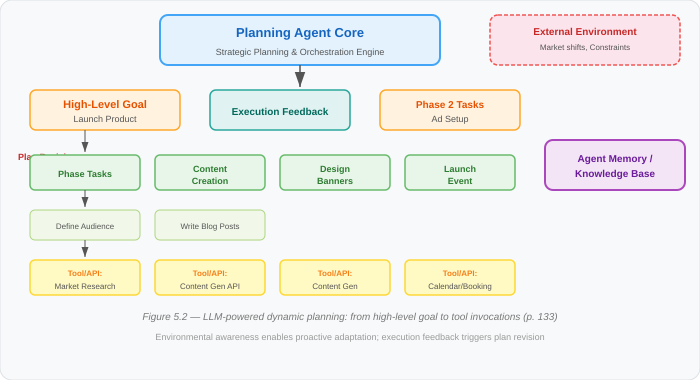

In [3]:
# ── Figure 5.2 — Planning Agent Architecture (SVG) ──

from IPython.display import SVG, display

fig_5_2 = """
<svg viewBox="0 0 700 380" xmlns="http://www.w3.org/2000/svg" font-family="Arial, sans-serif">
  <defs><marker id="a52" markerWidth="10" markerHeight="7" refX="10" refY="3.5" orient="auto"><polygon points="0 0,10 3.5,0 7" fill="#555"/></marker></defs>
  <rect width="700" height="380" rx="12" fill="#f8f9fa" stroke="#dee2e6"/>
  <!-- Planning Agent Core -->
  <rect x="160" y="15" width="280" height="50" rx="8" fill="#e3f2fd" stroke="#42a5f5" stroke-width="2"/>
  <text x="300" y="37" text-anchor="middle" font-size="13" font-weight="bold" fill="#1565c0">Planning Agent Core</text>
  <text x="300" y="55" text-anchor="middle" font-size="9" fill="#555">Strategic Planning &amp; Orchestration Engine</text>
  <!-- External Environment -->
  <rect x="490" y="15" width="190" height="50" rx="8" fill="#fce4ec" stroke="#ef5350" stroke-width="1.5" stroke-dasharray="4,2"/>
  <text x="585" y="35" text-anchor="middle" font-size="10" font-weight="bold" fill="#c62828">External Environment</text>
  <text x="585" y="50" text-anchor="middle" font-size="8" fill="#555">Market shifts, Constraints</text>
  <!-- Row 2: Goal + Feedback + Phase 2 -->
  <rect x="30" y="90" width="150" height="40" rx="6" fill="#fff3e0" stroke="#ffa726" stroke-width="1.5"/>
  <text x="105" y="108" text-anchor="middle" font-size="11" font-weight="bold" fill="#e65100">High-Level Goal</text>
  <text x="105" y="122" text-anchor="middle" font-size="9" fill="#555">Launch Product</text>
  <rect x="210" y="90" width="140" height="40" rx="6" fill="#e0f2f1" stroke="#26a69a" stroke-width="1.5"/>
  <text x="280" y="115" text-anchor="middle" font-size="10" font-weight="bold" fill="#00695c">Execution Feedback</text>
  <rect x="380" y="90" width="140" height="40" rx="6" fill="#fff3e0" stroke="#ffa726" stroke-width="1.5"/>
  <text x="450" y="108" text-anchor="middle" font-size="10" font-weight="bold" fill="#e65100">Phase 2 Tasks</text>
  <text x="450" y="122" text-anchor="middle" font-size="9" fill="#555">Ad Setup</text>
  <!-- Plan Revision -->
  <text x="18" y="160" font-size="9" font-weight="bold" fill="#c62828">Plan Revision</text>
  <!-- Row 3: Phase Tasks -->
  <rect x="30" y="155" width="110" height="35" rx="5" fill="#e8f5e9" stroke="#66bb6a" stroke-width="1.5"/>
  <text x="85" y="177" text-anchor="middle" font-size="9" font-weight="bold" fill="#2e7d32">Phase Tasks</text>
  <rect x="155" y="155" width="110" height="35" rx="5" fill="#e8f5e9" stroke="#66bb6a" stroke-width="1.5"/>
  <text x="210" y="172" text-anchor="middle" font-size="9" font-weight="bold" fill="#2e7d32">Content</text>
  <text x="210" y="184" text-anchor="middle" font-size="9" font-weight="bold" fill="#2e7d32">Creation</text>
  <rect x="280" y="155" width="110" height="35" rx="5" fill="#e8f5e9" stroke="#66bb6a" stroke-width="1.5"/>
  <text x="335" y="172" text-anchor="middle" font-size="9" font-weight="bold" fill="#2e7d32">Design</text>
  <text x="335" y="184" text-anchor="middle" font-size="9" font-weight="bold" fill="#2e7d32">Banners</text>
  <rect x="405" y="155" width="110" height="35" rx="5" fill="#e8f5e9" stroke="#66bb6a" stroke-width="1.5"/>
  <text x="460" y="172" text-anchor="middle" font-size="9" font-weight="bold" fill="#2e7d32">Launch</text>
  <text x="460" y="184" text-anchor="middle" font-size="9" font-weight="bold" fill="#2e7d32">Event</text>
  <!-- Knowledge Base -->
  <rect x="545" y="140" width="140" height="50" rx="8" fill="#f3e5f5" stroke="#ab47bc" stroke-width="2"/>
  <text x="615" y="162" text-anchor="middle" font-size="10" font-weight="bold" fill="#6a1b9a">Agent Memory /</text>
  <text x="615" y="177" text-anchor="middle" font-size="10" font-weight="bold" fill="#6a1b9a">Knowledge Base</text>
  <!-- Row 4: Subtasks -->
  <rect x="30" y="210" width="110" height="30" rx="5" fill="#f1f8e9" stroke="#aed581" stroke-width="1"/>
  <text x="85" y="229" text-anchor="middle" font-size="8" fill="#555">Define Audience</text>
  <rect x="155" y="210" width="110" height="30" rx="5" fill="#f1f8e9" stroke="#aed581" stroke-width="1"/>
  <text x="210" y="229" text-anchor="middle" font-size="8" fill="#555">Write Blog Posts</text>
  <!-- Row 5: Tool/API -->
  <rect x="30" y="260" width="110" height="35" rx="5" fill="#fff9c4" stroke="#fdd835" stroke-width="1.5"/>
  <text x="85" y="276" text-anchor="middle" font-size="8" font-weight="bold" fill="#f57f17">Tool/API:</text>
  <text x="85" y="289" text-anchor="middle" font-size="8" fill="#555">Market Research</text>
  <rect x="155" y="260" width="110" height="35" rx="5" fill="#fff9c4" stroke="#fdd835" stroke-width="1.5"/>
  <text x="210" y="276" text-anchor="middle" font-size="8" font-weight="bold" fill="#f57f17">Tool/API:</text>
  <text x="210" y="289" text-anchor="middle" font-size="8" fill="#555">Content Gen API</text>
  <rect x="280" y="260" width="110" height="35" rx="5" fill="#fff9c4" stroke="#fdd835" stroke-width="1.5"/>
  <text x="335" y="276" text-anchor="middle" font-size="8" font-weight="bold" fill="#f57f17">Tool/API:</text>
  <text x="335" y="289" text-anchor="middle" font-size="8" fill="#555">Content Gen</text>
  <rect x="405" y="260" width="110" height="35" rx="5" fill="#fff9c4" stroke="#fdd835" stroke-width="1.5"/>
  <text x="460" y="276" text-anchor="middle" font-size="8" font-weight="bold" fill="#f57f17">Tool/API:</text>
  <text x="460" y="289" text-anchor="middle" font-size="8" fill="#555">Calendar/Booking</text>
  <!-- Arrows -->
  <line x1="300" y1="65" x2="300" y2="87" stroke="#555" stroke-width="1.5" marker-end="url(#a52)"/>
  <line x1="85" y1="130" x2="85" y2="152" stroke="#555" stroke-width="1" marker-end="url(#a52)"/>
  <line x1="85" y1="190" x2="85" y2="207" stroke="#555" stroke-width="1" marker-end="url(#a52)"/>
  <line x1="85" y1="240" x2="85" y2="257" stroke="#555" stroke-width="1" marker-end="url(#a52)"/>
  <!-- Caption -->
  <text x="350" y="320" text-anchor="middle" font-size="10" fill="#777" font-style="italic">Figure 5.2 — LLM-powered dynamic planning: from high-level goal to tool invocations (p. 133)</text>
  <text x="350" y="340" text-anchor="middle" font-size="9" fill="#999">Environmental awareness enables proactive adaptation; execution feedback triggers plan revision</text>
</svg>
"""
display(SVG(fig_5_2))


In [4]:
# ── PlanningAgent Class ────────────────────────────────────────
#  Planning Agent
#
# Implements hierarchical task decomposition with dependency
# resolution via topological sort. The agent decomposes a
# high-level goal into phased subtasks, executes them in
# dependency order, monitors progress, and can revise the plan
# based on feedback.

log_section("Planning Agent")


class PlanningAgent:
    """Agent for orchestrating complex, multi-step workflows.

    Decomposes high-level goals into hierarchical task plans,
    executes them respecting dependency order via topological
    sort, and supports adaptive plan revision.

    """

    def __init__(self, llm_client_ref) -> None:
        """Initialize with an LLM client reference.

        Args:
            llm_client_ref: MockLLM or real LLM client instance.
        """
        self.llm = llm_client_ref
        self.execution_log: list[dict] = []
        self.plan_revisions: int = 0

    @fail_gracefully(
        fallback_value=[]
    )
    def decompose_goal(self, goal: str) -> list[dict]:
        """Decompose a high-level goal into a hierarchical task DAG.

        Uses the LLM to identify the goal type, then builds a
        structured task plan matching Figure 5.2's architecture.

        Args:
            goal: High-level objective string.

        Returns:
            List of task dicts with 'id', 'action', 'phase',
            'depends_on', and 'tools' keys.

        """
        response = self.llm.generate(goal)
        log_info(f"Goal decomposition: '{goal}'")
        log_info(f"LLM identified strategy: '{response.strategy}'")
        log_info(f"Response Intent: '{response.intent}'")

        # Ref: Figure 5.2 — marketing campaign task hierarchy
        if response.intent == "planning_request":
            plan = [
                # Phase 1: Research (Ref: Figure 5.2, left branch)
                {
                    "id": "P1-T1", "phase": 1,
                    "action": "define_target_audience",
                    "depends_on": [],
                    "tools": ["market_research_platform"],
                },
                {
                    "id": "P1-T2", "phase": 1,
                    "action": "competitive_analysis",
                    "depends_on": [],
                    "tools": ["market_research_platform"],
                },
                # Phase 2: Content Creation (Ref: Figure 5.2, center)
                {
                    "id": "P2-T1", "phase": 2,
                    "action": "write_blog_posts",
                    "depends_on": ["P1-T1"],
                    "tools": ["content_generation_api"],
                },
                {
                    "id": "P2-T2", "phase": 2,
                    "action": "design_banners",
                    "depends_on": ["P1-T1"],
                    "tools": ["content_generation_api"],
                },
                # Phase 3: Distribution (Ref: Figure 5.2, right)
                {
                    "id": "P3-T1", "phase": 3,
                    "action": "setup_ad_campaigns",
                    "depends_on": ["P2-T1", "P2-T2"],
                    "tools": ["ad_platform_api"],
                },
                {
                    "id": "P3-T2", "phase": 3,
                    "action": "schedule_launch_event",
                    "depends_on": ["P1-T2"],
                    "tools": ["calendar_booking_api"],
                },
                # Phase 4: Monitoring (Ref: Figure 5.2, feedback loop)
                {
                    "id": "P4-T1", "phase": 4,
                    "action": "monitor_campaign_metrics",
                    "depends_on": ["P3-T1", "P3-T2"],
                    "tools": ["analytics_dashboard"],
                },
                {
                    "id": "P4-T2", "phase": 4,
                    "action": "adaptive_revision_check",
                    "depends_on": ["P4-T1"],
                    "tools": [],
                },
            ]
        else:
            # Generic planning decomposition
            plan = [
                {"id": "G-T1", "phase": 1, "action": "analyze_requirements",
                 "depends_on": [], "tools": []},
                {"id": "G-T2", "phase": 2, "action": "design_solution",
                 "depends_on": ["G-T1"], "tools": []},
                {"id": "G-T3", "phase": 3, "action": "implement_solution",
                 "depends_on": ["G-T2"], "tools": []},
                {"id": "G-T4", "phase": 4, "action": "validate_results",
                 "depends_on": ["G-T3"], "tools": []},
            ]

        log_success(f"Decomposed into {len(plan)} tasks across "
                    f"{max(t['phase'] for t in plan)} phases")
        return plan

    @fail_gracefully(
        fallback_value=[],
    )
    def execute_plan(self, plan: list[dict]) -> list[dict]:
        """Execute a task plan respecting dependency order.

        Uses topological sort to determine execution order.
        Tasks with satisfied dependencies execute in phase order.
        Each task is individually wrapped for fault tolerance.

        Args:
            plan: Task DAG from decompose_goal().

        Returns:
            List of execution result dicts.

        """
        results = []
        completed: dict[str, dict] = {}
        remaining = list(plan)

        log_info("Beginning plan execution (topological order)...")

        while remaining:
            # Find tasks whose dependencies are all satisfied
            ready = [
                t for t in remaining
                if all(d in completed for d in t["depends_on"])
            ]
            if not ready:
                log_error("Deadlock: unresolvable dependencies remain")
                break

            for task in ready:
                result = self._execute_single_task(task)
                completed[task["id"]] = result
                results.append(result)
                remaining.remove(task)

                # Monitor progress (Ref: p. 134)
                self.monitor_progress(plan, completed)

        log_success(f"Plan execution complete: {len(results)}/{len(plan)} tasks")
        return results

    @fail_gracefully(
        fallback_value={"status": "task_failed"},

    )
    def _execute_single_task(self, task: dict) -> dict:
        """Execute a single task and return its result.

        Args:
            task: Task dict from the plan.

        Returns:
            Result dict with status, timing, and metadata.

        """
        tools_str = ", ".join(task["tools"]) if task["tools"] else "none"
        log_info(f"  Phase {task['phase']} | {task['id']}: "
                 f"{task['action']} (tools: {tools_str})")

        result = {
            "task_id": task["id"],
            "phase": task["phase"],
            "action": task["action"],
            "status": "completed",
            "timestamp": datetime.now().isoformat(),
        }
        log_success(f"  {task['id']}: completed")
        self.execution_log.append(result)
        return result

    def monitor_progress(
        self, plan: list[dict], completed: dict
    ) -> None:
        """Track execution progress and log phase completion.

        """
        total = len(plan)
        done = len(completed)
        pct = round(done / total * 100)

        # Check if a phase just completed
        completed_phases = set()
        for t in plan:
            if t["id"] in completed:
                completed_phases.add(t["phase"])

        # Log phase completions
        for phase in sorted(completed_phases):
            phase_tasks = [t for t in plan if t["phase"] == phase]
            if all(t["id"] in completed for t in phase_tasks):
                phase_actions = [t["action"] for t in phase_tasks]
                if done <= len(phase_tasks) or done == total:
                    log_info(f"  Progress: {pct}% ({done}/{total}) "
                             f"— Phase {phase} complete")

    @fail_gracefully(
        fallback_value=None,
        chapter_ref="Section 5.2, p. 134",
    )
    def revise_plan(
        self, plan: list[dict], feedback: str
    ) -> list[dict]:
        """Revise the plan based on execution feedback.

        Demonstrates the adaptive intelligence capability
        where the agent modifies strategies based on new
        information or changing conditions.

        Args:
            plan: Current task plan.
            feedback: Feedback string describing what changed.

        Returns:
            Revised plan (or original if no changes needed).

        """
        self.plan_revisions += 1
        log_warn(f"Plan revision #{self.plan_revisions}: {feedback}")

        # Simulate adding a corrective task
        max_phase = max(t["phase"] for t in plan)
        revision_task = {
            "id": f"REV-{self.plan_revisions}",
            "phase": max_phase + 1,
            "action": f"corrective_action_{self.plan_revisions}",
            "depends_on": [plan[-1]["id"]],
            "tools": [],
        }
        revised = plan + [revision_task]
        log_info(f"Added corrective task: {revision_task['id']}")
        return revised


log_success("PlanningAgent class defined")


────────────────────────────────────────────────────────────
  Planning Agent
────────────────────────────────────────────────────────────

[SUCCESS 18:28:54] PlanningAgent class defined


In [5]:
# ── Demo: Marketing Campaign Planning ──────────────────────────
#
# Scenario: "Launch Product Marketing Campaign"
# The agent decomposes this into phased tasks, executes them
# in dependency order, demonstrates the feedback loop, and
# shows adaptive plan revision.

log_section(
    "DEMO: Marketing Campaign Planning",
)

planner = PlanningAgent(llm_client)

# Step 1: Decompose the goal
campaign_plan = planner.decompose_goal("Launch Product Marketing Campaign")

print()
log_info("Task DAG overview:")
for task in campaign_plan:
    deps = task["depends_on"] if task["depends_on"] else ["(start)"]
    log_info(f"  Phase {task['phase']} | {task['id']}: "
             f"{task['action']} → depends_on: {deps}")

# Step 2: Execute the plan
print()
log_section("Executing Plan")
campaign_results = planner.execute_plan(campaign_plan)

# Step 3: Simulate adaptive revision
print()
log_section("Adaptive Revision")
revised_plan = planner.revise_plan(
    campaign_plan,
    feedback="Competitor launched similar campaign — need differentiation"
)

# Step 4: Execute the revision
revision_results = planner.execute_plan(
    [t for t in revised_plan if t["id"].startswith("REV-")]
)

# Summary
print()
log_section("Planning Demo Summary")
log_info(f"Original tasks: {len(campaign_plan)}")
log_info(f"After revision: {len(revised_plan)} (+{len(revised_plan) - len(campaign_plan)})")
log_info(f"Total executions: {len(planner.execution_log)}")
log_success("Marketing campaign planning demo complete")


────────────────────────────────────────────────────────────
  DEMO: Marketing Campaign Planning
────────────────────────────────────────────────────────────

[INFO  18:29:01] Goal decomposition: 'Launch Product Marketing Campaign'
[INFO  18:29:01] LLM identified strategy: 'full_autonomous_resolution'
[INFO  18:29:01] Response Intent: 'marketing_campaign_plan'
[SUCCESS 18:29:01] Decomposed into 4 tasks across 4 phases

[INFO  18:29:01] Task DAG overview:
[INFO  18:29:01]   Phase 1 | G-T1: analyze_requirements → depends_on: ['(start)']
[INFO  18:29:01]   Phase 2 | G-T2: design_solution → depends_on: ['G-T1']
[INFO  18:29:01]   Phase 3 | G-T3: implement_solution → depends_on: ['G-T2']
[INFO  18:29:01]   Phase 4 | G-T4: validate_results → depends_on: ['G-T3']


────────────────────────────────────────────────────────────
  Executing Plan
────────────────────────────────────────────────────────────

[INFO  18:29:01] Beginning plan execution (topological order)...
[INFO  18:29:01]   Phase 